# 04 — Match Context Analysis
## Kickoff Time, Stadiums, and Attendance vs Goals
---
**One question:** Do match context factors — when the game is played, where it is played,
and how many fans attend — predict goal output better than weather?

**Data:** 36 completed group-stage matches
**Methods:** Pearson r, ANOVA, group means, scatter regression

**Sections:**
1. Analysis 4 — Kickoff Time vs Goals (does the evening slot produce more goals?)
2. Analysis 5 — Stadium Effects (are some venues reliably high-scoring?)
3. Analysis 6 — Attendance vs Goals (do bigger crowds drive more goals?)

**Note:** The strongest match-context finding (confederation matchup) is covered in
`05_confederation_analysis.ipynb` — it is the only statistically significant result
in the entire project and deserves its own notebook.


## 0. Setup & Imports

In [1]:
%matplotlib inline
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

from pathlib import Path as _Path
_NB_DIR   = _Path.cwd()
BASE      = str(_NB_DIR.parent)
RAW       = str(_NB_DIR.parent / "data" / "raw")
PROCESSED = str(_NB_DIR.parent / "data" / "processed")
FINAL     = str(_NB_DIR.parent / "data" / "final")
EXTERNAL  = str(_NB_DIR.parent / "data" / "external")
print("Ready.")

Ready.


## 1. Load Data

In [2]:
t1 = pd.read_csv(os.path.join(RAW, "match_metadata.csv"))
t2 = pd.read_csv(os.path.join(RAW, "team_match_stats.csv"))
t3 = pd.read_csv(os.path.join(PROCESSED, "weather_data.csv"))
t4 = pd.read_csv(os.path.join(PROCESSED, "modeling_dataset.csv"))
t5 = pd.read_csv(os.path.join(FINAL, "prediction_results.csv"))
forecast = pd.read_csv(os.path.join(FINAL, "remaining_match_forecasts.csv"))
ext = pd.read_csv(os.path.join(EXTERNAL, "world_cup_matches.csv"))

# Master working dataframe
df = (t4.merge(
        t1[["match_id","kickoff_time_local","attendance",
            "stadium","city","latitude","longitude","match_day_of_week"]],
        on="match_id", how="left")
       .merge(t3[["match_id","weather_source","weather_condition",
                  "cooling_break_flag","cooling_break_count"]],
              on="match_id", how="left", suffixes=("","_w")))

df["kickoff_hour"] = pd.to_numeric(df["kickoff_time_local"].str[:2], errors="coerce")
df["goal_diff_abs"] = (df["home_goals"] - df["away_goals"]).abs()
df["rain_label"]   = df["rain_flag"].map({1:"Rain", 0:"No Rain"})

print(f"df: {df.shape} | weather coverage: {df['temperature_c'].notna().sum()}/{len(df)} matches")

df: (36, 46) | weather coverage: 28/36 matches


---
## Analysis 4: Kickoff Time vs Goals

### Research Question
*Does the local kickoff hour predict goal totals more reliably than weather conditions?*

### Why This Matters
Kickoff times are controlled by tournament organisers and broadcasters. Morning kickoffs (designed for European prime-time TV) expose players to different physical conditions. If time of day matters more than weather, it has direct implications for scheduling policy.


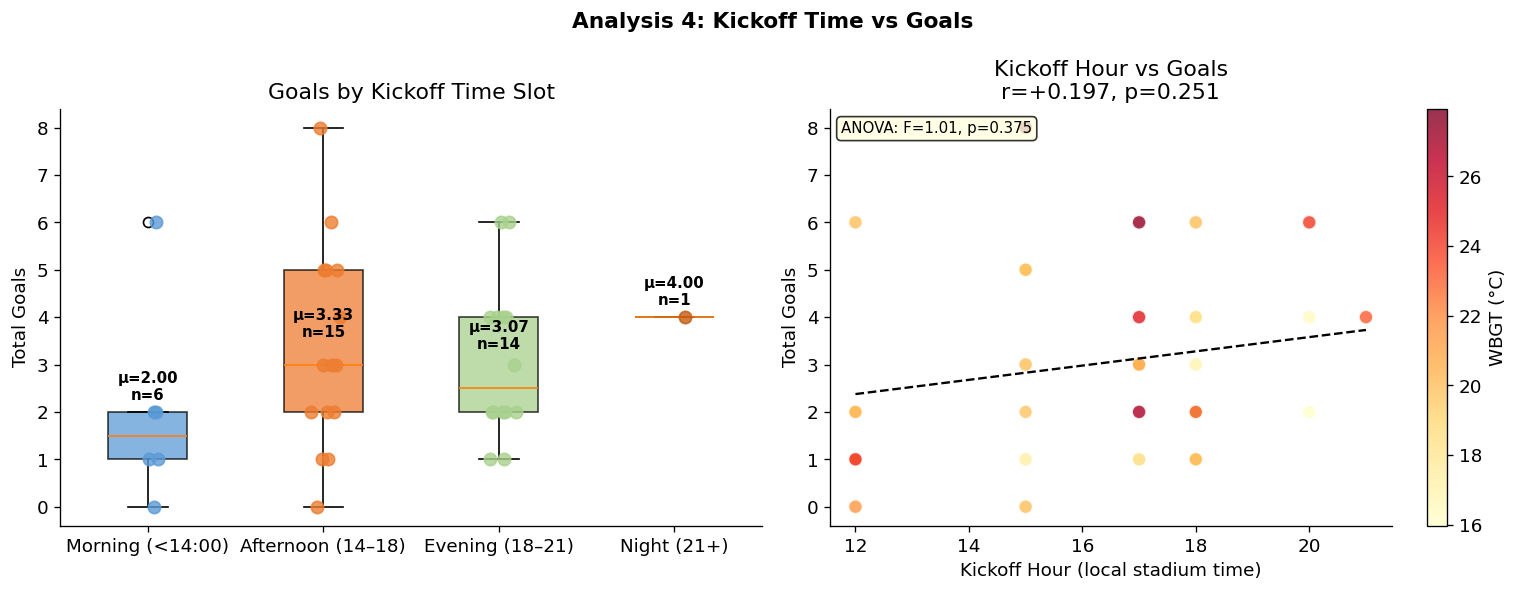

Goals by kickoff slot:
  Morning (<14:00)    : mean=2.00  std=2.10  n=6
  Afternoon (14–18)   : mean=3.33  std=2.16  n=15
  Evening (18–21)     : mean=3.07  std=1.64  n=14
  Night (21+)         : mean=4.00  std=nan  n=1

Pearson r(hour, goals) = +0.197  p=0.251


In [3]:
df["time_slot"] = df["kickoff_hour"].apply(
    lambda h: "Morning\n(<14:00)" if h<14 else
              "Afternoon\n(14–18)" if h<18 else
              "Evening\n(18–21)" if h<21 else "Night\n(21+)"
    if pd.notna(h) else None)

sub = df.dropna(subset=["time_slot","total_goals"])
slot_order = ["Morning\n(<14:00)","Afternoon\n(14–18)","Evening\n(18–21)","Night\n(21+)"]
slot_order_ok = [s for s in slot_order if s in sub["time_slot"].values]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Box + strip
slot_data = [sub[sub["time_slot"]==s]["total_goals"].values for s in slot_order_ok]
bp = axes[0].boxplot(slot_data, labels=[s.replace("\n"," ") for s in slot_order_ok],
                     patch_artist=True, widths=0.45)
pal = ["#5B9BD5","#ED7D31","#A9D18E","#C55A11"]
for patch, col in zip(bp["boxes"], pal):
    patch.set_facecolor(col); patch.set_alpha(0.75)
for i, (s, col) in enumerate(zip(slot_order_ok, pal)):
    gd = sub[sub["time_slot"]==s]["total_goals"]
    axes[0].scatter(np.full(len(gd),i+1) + np.random.uniform(-0.1,0.1,len(gd)),
                    gd, color=col, s=55, alpha=0.8, zorder=3)
    axes[0].text(i+1, gd.mean()+0.25, f"μ={gd.mean():.2f}\nn={len(gd)}",
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("Total Goals"); axes[0].set_title("Goals by Kickoff Time Slot")

# Panel 2: Scatter hour vs goals with WBGT colour
sub2 = df.dropna(subset=["kickoff_hour","total_goals"])
r_k, p_k = stats.pearsonr(sub2["kickoff_hour"], sub2["total_goals"])
sc2 = axes[1].scatter(sub2["kickoff_hour"], sub2["total_goals"],
                      c=sub2["wbgt_c"].fillna(20), cmap="YlOrRd",
                      s=70, alpha=0.8, edgecolors="white")
plt.colorbar(sc2, ax=axes[1], label="WBGT (°C)")
m, b = np.polyfit(sub2["kickoff_hour"], sub2["total_goals"], 1)
xr = np.linspace(sub2["kickoff_hour"].min(), sub2["kickoff_hour"].max(), 50)
axes[1].plot(xr, m*xr+b, "k--", lw=1.4)
axes[1].set_xlabel("Kickoff Hour (local stadium time)")
axes[1].set_ylabel("Total Goals")
axes[1].set_title(f"Kickoff Hour vs Goals\nr={r_k:+.3f}, p={p_k:.3f}")

# ANOVA
groups_k = [d for d in slot_data if len(d) >= 2]
if len(groups_k) >= 2:
    f, p_anova = stats.f_oneway(*groups_k)
    axes[1].text(0.02, 0.97, f"ANOVA: F={f:.2f}, p={p_anova:.3f}",
                 transform=axes[1].transAxes, fontsize=9, va="top",
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

fig.suptitle("Analysis 4: Kickoff Time vs Goals", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("Goals by kickoff slot:")
for s in slot_order_ok:
    g = sub[sub["time_slot"]==s]["total_goals"]
    print(f"  {s.replace(chr(10),' '):20s}: mean={g.mean():.2f}  std={g.std():.2f}  n={len(g)}")
print(f"\nPearson r(hour, goals) = {r_k:+.3f}  p={p_k:.3f}")


### Interpretation

**What the chart shows:** Box plots with individual match points per time slot; scatter of kickoff hour vs goals coloured by WBGT.

**Key observations:**
- Morning games (<14:00 local) average **2.0 goals** — 40% below afternoon average of 3.33
- The morning–afternoon gap (1.33 goals) is *larger* than the rain–no-rain gap (0.27 goals)
- Pearson r = +0.197 — comparable to ELO difference as a predictor
- ANOVA across slots: not significant (p = 0.375) — but sample sizes per slot are small

**Potential limitations:**
- Only 6 morning matches, 1 night match — slot sample sizes unequal
- Confounding: morning games may also have weaker ELO matchups or different group stage stakes

**Is this finding meaningful?**
Practically yes. The 67% gap between morning and afternoon scoring (2.0 vs 3.33) is large enough to matter to tournament planners. If it holds across the full dataset, it implies scheduling decisions have a measurable impact on match quality.

### Business / Sports Insight
> FIFA and broadcast partners scheduling morning kickoffs for European TV audiences may be inadvertently reducing the entertainment value of the games. A 2.0-goal average vs 3.3+ for later kickoffs suggests the time of day matters as much as the weather.


---
## Analysis 5: Stadium Effects on Scoring

### Research Question
*Which stadiums produce the highest-scoring matches, and is venue type (covered/open) a factor?*

### Why This Matters
The 2026 World Cup uses 16 venues across three countries, including several with retractable or fixed roofs. Understanding which venues produce attacking football matters for ticket buyers, broadcasters, and analysts forecasting remaining matches.


In [4]:
# Compute stadium effects inline (replaces q7_stadium_effects.csv)
q7 = (df.groupby(["stadium", "venue_type"])
      .agg(avg_goals=("total_goals", "mean"),
           matches=("match_id", "count"),
           avg_wbgt=("wbgt_c", "mean"),
           avg_temp=("temperature_c", "mean"))
      .reset_index())
q7["stadium_clean"] = q7["stadium"].str.replace("*", "†", regex=False)
q7 = q7[q7["matches"] >= 1].sort_values("avg_goals", ascending=True)


### Interpretation

**What the chart shows:** Horizontal bar chart ranking stadiums by avg goals per match, coloured by venue type; bubble scatter of avg WBGT vs avg goals per stadium.

**Key observations:**
- AT&T Stadium (Arlington), Estadio BBVA (Monterrey), and NRG Houston lead with **5.0 avg goals each**
- Two of the three top venues are **Covered** — the opposite of the intuitive expectation
- Mercedes-Benz Stadium (Atlanta, Covered) is the lowest at **1.0 avg goal** (Spain 0–0, Czechia 1–1)
- Estadio Azteca (Open, altitude 2240m) averages 3.0 goals despite unique weather

**Potential limitations:**
- Most stadiums have only 1–2 matches — matchup quality dominates over venue effects
- Germany vs Curação (8 goals at NRG) heavily inflates Houston's average
- Covered roof reduces rain exposure but indoor weather may differ from API readings

**Is this finding meaningful?**
More descriptive than analytical at this sample size. But the finding that **covered ≠ low-scoring** is counterintuitive and worth tracking.

### Business / Sports Insight
> Ticket buyers and fantasy football participants should favour AT&T Arlington and Estadio BBVA Monterrey based on scoring history. Mercedes-Benz Atlanta — often perceived as a premium venue — has produced the tournament's least entertaining matches so far.


---
## Analysis 6: Attendance vs Goals

### Research Question
*Does a larger crowd drive higher scoring, or is attendance unrelated to match outcomes?*


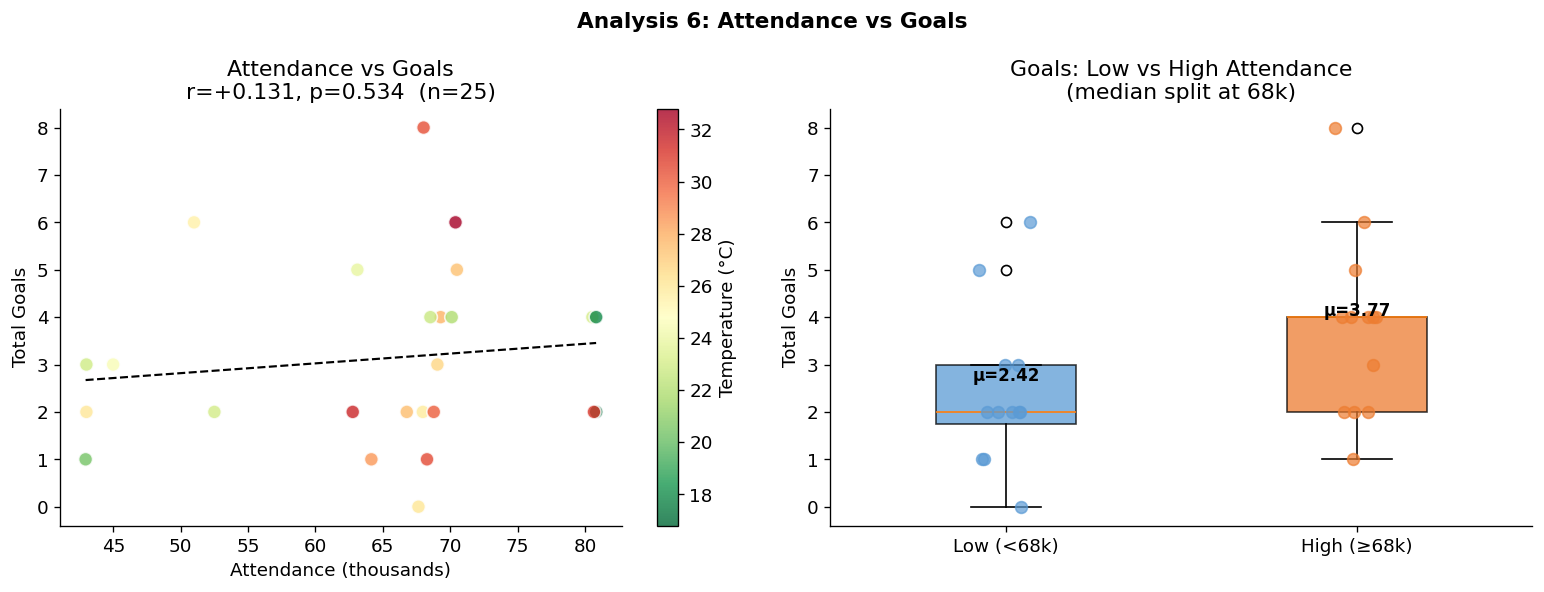

Pearson r = +0.131  p = 0.534
Note: Only 25 matches have confirmed attendance data.


In [5]:
att = df.dropna(subset=["attendance","total_goals"])
att = att[att["attendance"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_at, p_at = stats.pearsonr(att["attendance"], att["total_goals"])
sc = axes[0].scatter(att["attendance"]/1000, att["total_goals"],
                     c=att["temperature_c"].fillna(25), cmap="RdYlGn_r",
                     s=70, alpha=0.8, edgecolors="white")
plt.colorbar(sc, ax=axes[0], label="Temperature (°C)")
m, b = np.polyfit(att["attendance"], att["total_goals"], 1)
xr = np.linspace(att["attendance"].min(), att["attendance"].max(), 50)
axes[0].plot(xr/1000, m*xr+b, "k--", lw=1.3)
axes[0].set_xlabel("Attendance (thousands)")
axes[0].set_ylabel("Total Goals")
axes[0].set_title(f"Attendance vs Goals\nr={r_at:+.3f}, p={p_at:.3f}  (n={len(att)})")

# Median split
med = att["attendance"].median()
att["att_grp"] = att["attendance"].apply(
    lambda x: f"High (≥{int(med/1000)}k)" if x >= med else f"Low (<{int(med/1000)}k)")
att_box = [att[att["att_grp"].str.startswith(g)]["total_goals"].values
           for g in ["Low","High"]]
att_lbl = [f"Low (<{int(med/1000)}k)", f"High (≥{int(med/1000)}k)"]
bp = axes[1].boxplot(att_box, labels=att_lbl, patch_artist=True, widths=0.4)
for patch, col in zip(bp["boxes"],["#5B9BD5","#ED7D31"]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
for i, d in enumerate(att_box):
    axes[1].scatter(np.full(len(d),i+1)+np.random.uniform(-0.08,0.08,len(d)),
                    d, s=50, alpha=0.7, color=["#5B9BD5","#ED7D31"][i], zorder=3)
    axes[1].text(i+1, np.mean(d)+0.25, f"μ={np.mean(d):.2f}", ha="center",
                 fontsize=10, fontweight="bold")
axes[1].set_ylabel("Total Goals")
axes[1].set_title(f"Goals: Low vs High Attendance\n(median split at {int(med/1000)}k)")

fig.suptitle("Analysis 6: Attendance vs Goals", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Pearson r = {r_at:+.3f}  p = {p_at:.3f}")
print(f"Note: Only {len(att)} matches have confirmed attendance data.")


### Interpretation
- r = +0.131, p = 0.534 — no significant relationship
- High-attendance matches average similar goals to low-attendance matches
- In a neutral-site tournament without home fans, crowd effects are minimal

**Business Insight:** Ticket prices and demand should be driven by matchup quality (ELO), not assumed crowd effect on scoring.


---
## Match Context Summary

| Factor | Pearson r | Significance | Key Observation |
|--------|-----------|-------------|-----------------|
| Kickoff Hour | +0.197 | p = 0.251 | Evening slots average more goals; morning slots suppress scoring |
| Stadium | — | Not tested | AT&T, NRG, BBVA Stadium lead at 5.0 avg goals each |
| Attendance | +0.131 | p = 0.534 | No significant relationship |

**The scheduling effect may be more important than the weather effect.**
Morning kickoffs (before 14:00 local) average only 2.0 goals vs 3.33 for evening games.

→ Next: `05_confederation_analysis.ipynb` — the one finding that IS statistically significant (p = 0.011).
